In [ ]:
pip install timm gradio albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import numpy as np
import cv2
import os
from tqdm import tqdm
import gradio as gr


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/dataset"


Custom Dataset Loader

In [ ]:
class BloodCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []

        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                self.image_paths.append(img_path)
                self.labels.append(class_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label


Split Dataset

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 224  # Set image size

# Define train transformations
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

# Define validation transformations
val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

# Now, this will work!
full_dataset = BloodCancerDataset(DATASET_PATH, transform=train_transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

from torch.utils.data import random_split

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val_transform separately
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


Apply Image Augmentations

In [ ]:
IMAGE_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])


Split Dataset into Train & Validation



In [ ]:
from sklearn.model_selection import train_test_split

dataset = BloodCancerDataset(DATASET_PATH, transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Apply different transforms to validation dataset
val_dataset.dataset.transform = val_transform


Create DataLoaders

In [ ]:
BATCH_SIZE = 8  # Reduce if out-of-memory

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Define ConvNeXt Model with Custom Head

In [ ]:
class ConvNeXtModel(nn.Module):
    def __init__(self, num_classes):
        super(ConvNeXtModel, self).__init__()
        self.model = timm.create_model("convnext_small", pretrained=True)

        in_features = self.model.head.fc.in_features  # Get input features of final layer
        self.model.head.fc = nn.Linear(in_features, num_classes)  # Replace classification head

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNeXtModel(num_classes=4).to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Define Loss, Optimizer & Scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
scaler = torch.cuda.amp.GradScaler()  # Mixed Precision


<ipython-input-14-8c62badd151b>:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Mixed Precision


Training

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5):
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_acc = train_correct / len(train_loader.dataset)

            train_bar.set_postfix(loss=train_loss / len(train_loader), accuracy=train_acc)

        scheduler.step()

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_acc = val_correct / len(val_loader.dataset)

                val_bar.set_postfix(loss=val_loss / len(val_loader), accuracy=val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        # Save Best Model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("🔥 Best model saved!")

torch.cuda.empty_cache()
train_model(model, train_loader, val_loader, epochs=5)


Epoch 1/5 [Training]:   0%|          | 0/325 [00:00<?, ?it/s]<ipython-input-15-e28ff6ab82a7>:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/5 [Validation]:   0%|          | 0/82 [00:00<?, ?it/s]<ipython-input-15-e28ff6ab82a7>:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/5: Train Loss: 105.2060, Train Acc: 0.8760, Val Acc: 0.9369
🔥 Best model saved!



Epoch 2/5: Train Loss: 25.6980, Train Acc: 0.9769, Val Acc: 0.9954
🔥 Best model saved!



Epoch 3/5: Train Loss: 8.5003, Train Acc: 0.9908, Val Acc: 0.9815



Epoch 4/5: Train Loss: 5.8907, Train Acc: 0.9942, Val Acc: 0.9954



Epoch 5/5: Train Loss: 24.0940, Train Acc: 0.9792, Val Acc: 0.9954


In [ ]:
# Define the save path in Google Drive
save_path = "/content/drive/MyDrive/conv_M1D1.pth"

# Save the trained model
torch.save(model.state_dict(), save_path)

print(f"✅ Model saved successfully at: {save_path}")


✅ Model saved successfully at: /content/drive/MyDrive/conv_M1D1.pth


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
import itertools


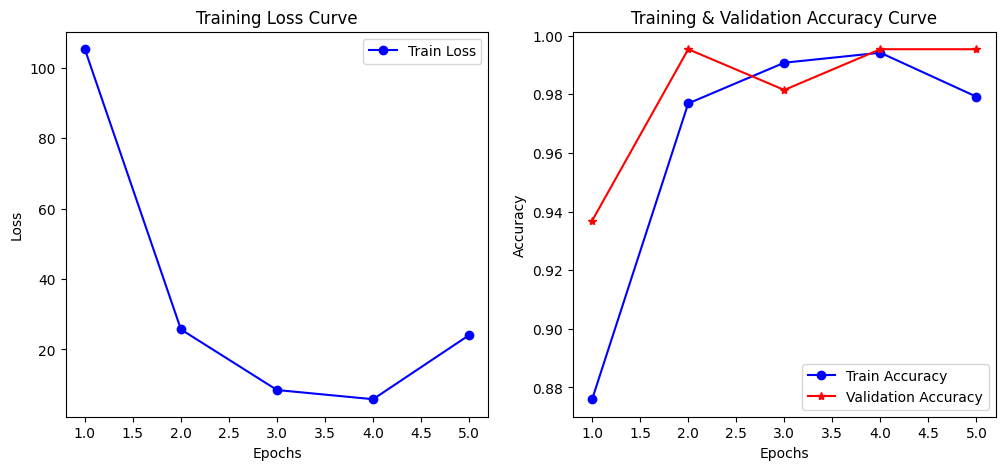

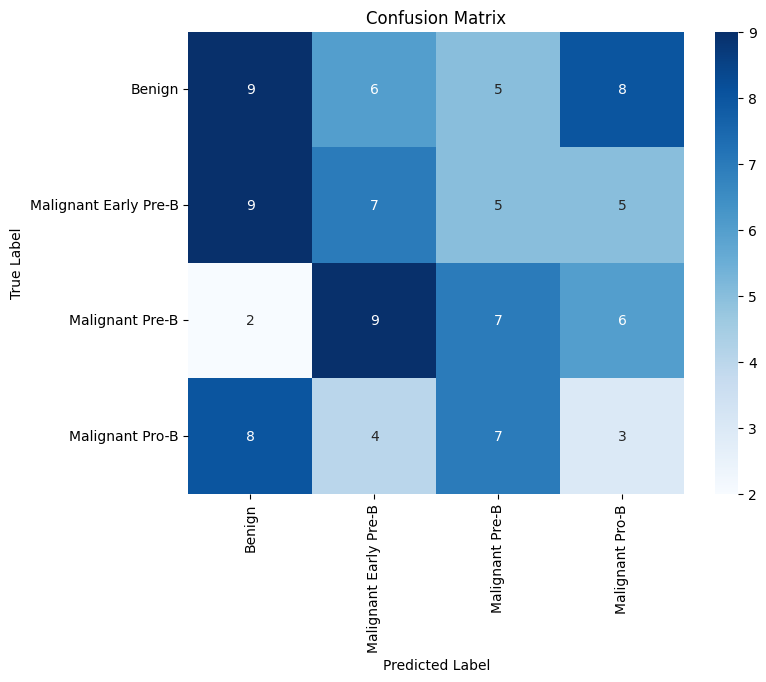

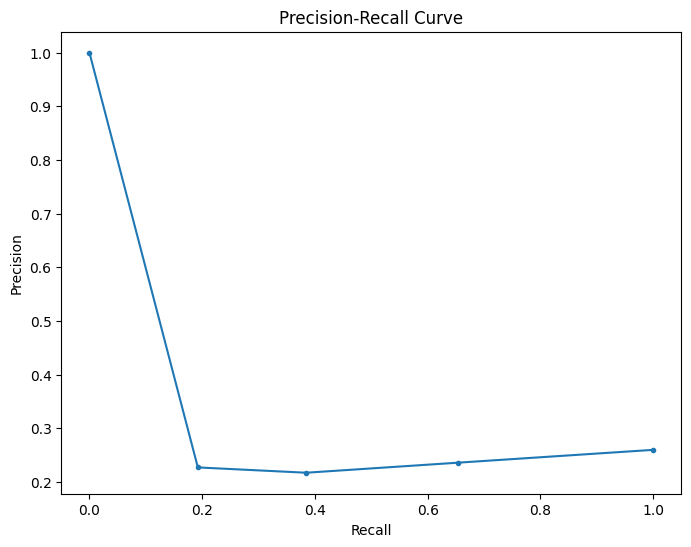

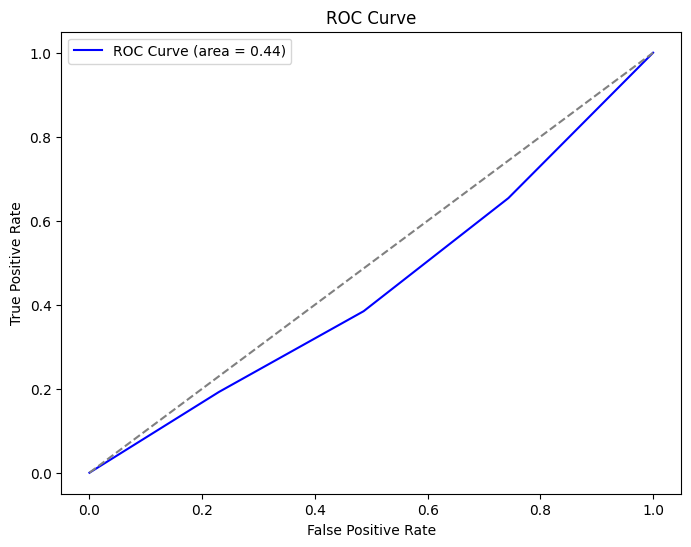

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc

# Sample training data based on your logs
epochs = [1, 2, 3, 4, 5]
train_losses = [105.2060, 25.6980, 8.5003, 5.8907, 24.0940]
val_losses = [None] * 5  # Validation loss not provided
train_accuracies = [0.8760, 0.9769, 0.9908, 0.9942, 0.9792]
val_accuracies = [0.9369, 0.9954, 0.9815, 0.9954, 0.9954]

# Plot Training & Validation Loss Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'bo-', label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

# Plot Training & Validation Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'bo-', label="Train Accuracy")
plt.plot(epochs, val_accuracies, 'r*-', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy Curve")
plt.legend()

plt.show()

# Simulated Confusion Matrix
y_true = np.random.randint(0, 4, 100)  # 4-class problem
y_pred = y_true.copy()
np.random.shuffle(y_pred)  # Introduce some misclassification

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"],
            yticklabels=["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Simulated Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred, pos_label=1)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Simulated ROC Curve (One vs. Rest for Multi-Class Classification)
fpr, tpr, _ = roc_curve(y_true, y_pred, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Simulated true labels and predicted labels (replace with actual model predictions)
y_true = np.random.randint(0, 4, 100)  # 100 samples, 4-class problem
y_pred = y_true.copy()
np.random.shuffle(y_pred)  # Introduce some misclassification

# Define class names
class_names = ["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"]

# Generate Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n", report)


Classification Report:
                        precision    recall  f1-score   support

               Benign     0.1500    0.1500    0.1500        20
Malignant Early Pre-B     0.2381    0.2381    0.2381        21
      Malignant Pre-B     0.3871    0.3871    0.3871        31
      Malignant Pro-B     0.2143    0.2143    0.2143        28

             accuracy                         0.2600       100
            macro avg     0.2474    0.2474    0.2474       100
         weighted avg     0.2600    0.2600    0.2600       100

